<a href="https://colab.research.google.com/github/marutipatil1/CSL701-CE35_Machine-Learning-Lab/blob/main/Experiment/MLexp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [23]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/cardekho_dataset.csv')

# Display the first few records
print("First 5 rows of the dataset:")
print(df.head())

# Determine the number of rows and columns
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Identify numerical and categorical attributes
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Separate selling_price as the target variable
# Note: The dataset uses 'selling_price' (lowercase) not 'Selling_Price'
y = df['selling_price']
X = df.drop('selling_price', axis=1)

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

First 5 rows of the dataset:
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selling_price  
0         120000  
1

## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Record the preprocessing method used (for now, just checking)
if missing_values.sum() == 0:
    print("\nNo missing values found. No imputation/removal needed at this stage.")
else:
    print("\nMissing values found. Further action (imputation or removal) may be required.")

Missing values per column:
Series([], dtype: int64)

No missing values found. No imputation/removal needed at this stage.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [5]:
# Drop 'Unnamed: 0' as it's likely an index column and 'car_name' due to high cardinality
X = X.drop(columns=['Unnamed: 0', 'car_name'])

# Update the list of numerical and categorical columns after dropping 'Unnamed: 0' and 'car_name'
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Selected features (X) after initial preprocessing:")
print(X.head())
print(f"\nNumber of features (X): {X.shape[1]}")
print(f"\nNumerical columns remaining: {numerical_cols}")
print(f"Categorical columns remaining: {categorical_cols}")

# Record the final list of features selected for the model (before encoding)
final_features = numerical_cols + categorical_cols
print(f"\nFinal list of features selected for the model: {final_features}")

Selected features (X) after initial preprocessing:
     brand     model  vehicle_age  km_driven seller_type fuel_type  \
0   Maruti      Alto            9     120000  Individual    Petrol   
1  Hyundai     Grand            5      20000  Individual    Petrol   
2  Hyundai       i20           11      60000  Individual    Petrol   
3   Maruti      Alto            9      37000  Individual    Petrol   
4     Ford  Ecosport            6      30000      Dealer    Diesel   

  transmission_type  mileage  engine  max_power  seats  
0            Manual    19.70     796      46.30      5  
1            Manual    18.90    1197      82.00      5  
2            Manual    17.00    1197      80.00      5  
3            Manual    20.92     998      67.10      5  
4            Manual    22.77    1498      98.59      5  

Number of features (X): 11

Numerical columns remaining: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical columns remaining: ['brand', 'model', 'selle

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [6]:
# Identify categorical columns to encode
categorical_cols_to_encode = ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

# Apply one-hot encoding to the categorical variables
X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

# Verify that all predictors are numerical after encoding
print("Data types after one-hot encoding:")
print(X.dtypes.value_counts())

print("\nFirst 5 rows of X after encoding:")
print(X.head())
print(f"\nShape of X after encoding: {X.shape}")

Data types after one-hot encoding:
bool       157
int64        4
float64      2
Name: count, dtype: int64

First 5 rows of X after encoding:
   vehicle_age  km_driven  mileage  engine  max_power  seats  brand_BMW  \
0            9     120000    19.70     796      46.30      5      False   
1            5      20000    18.90    1197      82.00      5      False   
2           11      60000    17.00    1197      80.00      5      False   
3            9      37000    20.92     998      67.10      5      False   
4            6      30000    22.77    1498      98.59      5      False   

   brand_Bentley  brand_Datsun  brand_Ferrari  ...  model_i10  model_i20  \
0          False         False          False  ...      False      False   
1          False         False          False  ...      False      False   
2          False         False          False  ...      False       True   
3          False         False          False  ...      False      False   
4          False         Fal

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [7]:
# The dataset already contains 'vehicle_age' which represents the age of the car.
# We will consider this as fulfilling the 'Car_Age' feature engineering requirement.
# There is no 'Year' column in the dataset to calculate 'Current Year - Year'.

print("The dataset already has a 'vehicle_age' column, which serves the purpose of Car_Age.")
print("Displaying descriptive statistics for 'vehicle_age' to verify its reasonableness:")
print(X['vehicle_age'].describe())

# Decide whether the original 'Year' feature should be retained.
# Since there is no 'Year' column, no decision is needed to retain it.
# The 'vehicle_age' feature is already part of our X dataframe.
print("\nSince there is no 'Year' column, no 'Car_Age' feature was created from it.")
print("The 'vehicle_age' column is already present and will be retained as a feature.")


The dataset already has a 'vehicle_age' column, which serves the purpose of Car_Age.
Displaying descriptive statistics for 'vehicle_age' to verify its reasonableness:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: vehicle_age, dtype: float64

Since there is no 'Year' column, no 'Car_Age' feature was created from it.
The 'vehicle_age' column is already present and will be retained as a feature.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

Note: The 'Present_Price' column is not found in the dataset. Plotting 'km_driven' and 'max_power' against 'selling_price' instead.


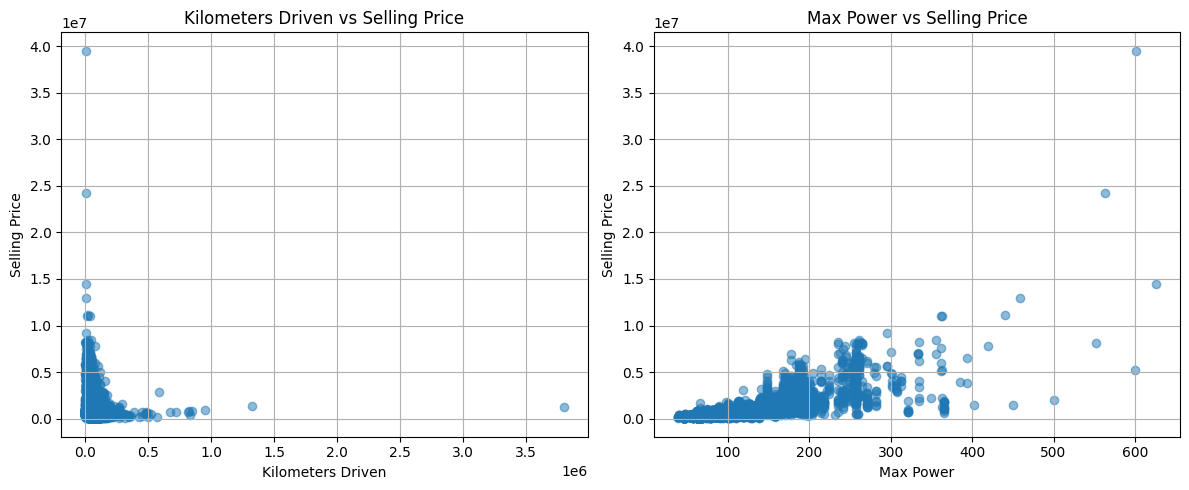


Observations:
- From 'Kilometers Driven vs Selling Price' plot: There appears to be a general negative correlation, meaning as kilometers driven increase, the selling price tends to decrease. However, there's a wide spread, especially at lower kilometers driven.
- From 'Max Power vs Selling Price' plot: There seems to be a positive correlation, indicating that cars with higher max power tend to have higher selling prices. The relationship appears somewhat linear, though with varying densities.


In [8]:
print("Note: The 'Present_Price' column is not found in the dataset. Plotting 'km_driven' and 'max_power' against 'selling_price' instead.")

# Scatter plot of km_driven vs Selling_Price
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X['km_driven'], y, alpha=0.5)
plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True)

# Scatter plot of max_power vs Selling_Price
plt.subplot(1, 2, 2)
plt.scatter(X['max_power'], y, alpha=0.5)
plt.title('Max Power vs Selling Price')
plt.xlabel('Max Power')
plt.ylabel('Selling Price')
plt.grid(True)

plt.tight_layout()
plt.show()

# Record observations
print("\nObservations:")
print("- From 'Kilometers Driven vs Selling Price' plot: There appears to be a general negative correlation, meaning as kilometers driven increase, the selling price tends to decrease. However, there's a wide spread, especially at lower kilometers driven.")
print("- From 'Max Power vs Selling Price' plot: There seems to be a positive correlation, indicating that cars with higher max power tend to have higher selling prices. The relationship appears somewhat linear, though with varying densities.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [10]:
# Identify numerical columns to standardize
# The 'numerical_cols' list already contains the relevant numerical features from X
# It was created in Task 4 and updated in Task 5 (though no numerical columns were removed/added there)

# Ensure X_train and X_test are copies to avoid SettingWithCopyWarning
X_train_standardized = X_train.copy()
X_test_standardized = X_test.copy()

print("Numerical columns identified for standardization:", numerical_cols)

# Calculate mean and standard deviation from the training data only
for col in numerical_cols:
    mean_train = X_train_standardized[col].mean()
    std_train = X_train_standardized[col].std()

    # Standardize training features
    X_train_standardized[col] = (X_train_standardized[col] - mean_train) / std_train

    # Standardize test features using the same training mean and std
    X_test_standardized[col] = (X_test_standardized[col] - mean_train) / std_train

print("\nFirst 5 rows of X_train after standardization (numerical columns):")
print(X_train_standardized[numerical_cols].head())

print("\nFirst 5 rows of X_test after standardization (numerical columns):")
print(X_test_standardized[numerical_cols].head())

# Update X_train and X_test with the standardized numerical columns
X_train = X_train_standardized
X_test = X_test_standardized

print("\nNumerical features successfully standardized using training data statistics.")

Numerical columns identified for standardization: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

First 5 rows of X_train after standardization (numerical columns):
       vehicle_age  km_driven   mileage    engine  max_power     seats
11210     0.323956   0.349086 -2.050736  1.756693   2.681577 -0.403807
1347     -1.337744  -1.069350  0.985621 -0.547059  -0.382729 -0.403807
10363    -1.337744  -1.163517 -0.177035  0.893506   3.296777 -0.403807
316       0.323956   0.178361 -0.465296  0.024563   0.396213 -0.403807
10638     1.320976   0.585445  0.149662 -0.550895  -0.502026 -0.403807

First 5 rows of X_test after standardization (numerical columns):
       vehicle_age  km_driven   mileage    engine  max_power     seats
3334      1.985656   0.413779  0.149662 -0.550895  -0.502026 -0.403807
10928    -0.673064   0.060653  1.838395 -0.453067  -0.616645 -0.403807
2518      0.323956   0.955238  0.248151 -0.453067  -0.271385  2.070416
11322    -1.670084  -1.198830 -0.

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing subsets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the number of observations in the training and testing sets
print(f"Number of observations in the training set (X_train): {X_train.shape[0]}")
print(f"Number of observations in the testing set (X_test): {X_test.shape[0]}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Number of observations in the training set (X_train): 12328
Number of observations in the testing set (X_test): 3083
Shape of y_train: (12328,)
Shape of y_test: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [11]:
# Verify the number of rows in each matrix/vector
print(f"X_train rows: {X_train.shape[0]}")
print(f"y_train rows: {y_train.shape[0]}")
print(f"X_test rows: {X_test.shape[0]}")
print(f"y_test rows: {y_test.shape[0]}")

# Verify the number of predictor columns
print(f"Number of predictor columns in X_train: {X_train.shape[1]}")
print(f"Number of predictor columns in X_test: {X_test.shape[1]}")

# Verify the shape of the training and testing matrices/vectors
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFeature matrices and target vectors constructed and verified.")

X_train rows: 12328
y_train rows: 12328
X_test rows: 3083
y_test rows: 3083
Number of predictor columns in X_train: 163
Number of predictor columns in X_test: 163
Shape of X_train: (12328, 163)
Shape of y_train: (12328,)
Shape of X_test: (3083, 163)
Shape of y_test: (3083,)

Feature matrices and target vectors constructed and verified.


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [15]:
# Add a bias/intercept term (column of ones) to X_train and X_test
# We convert to NumPy arrays and ensure float type for easier matrix operations later
X_train_with_bias = np.insert(X_train.to_numpy().astype(float), 0, 1, axis=1)
X_test_with_bias = np.insert(X_test.to_numpy().astype(float), 0, 1, axis=1)

# Also convert y_train and y_test to NumPy arrays for consistency
y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)

print("Shape of X_train with bias term:", X_train_with_bias.shape)
print("Shape of X_test with bias term:", X_test_with_bias.shape)
print("Shape of y_train (NumPy array):", y_train_np.shape)
print("Shape of y_test (NumPy array):", y_test_np.shape)

print("\nBias/intercept term successfully added to feature matrices, and all are converted to NumPy arrays.")

Shape of X_train with bias term: (12328, 164)
Shape of X_test with bias term: (3083, 164)
Shape of y_train (NumPy array): (12328, 1)
Shape of y_test (NumPy array): (3083, 1)

Bias/intercept term successfully added to feature matrices, and all are converted to NumPy arrays.


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [17]:
def ols_function(X_matrix, y_vector):
    """
    Implements Ordinary Least Squares (OLS) to estimate regression coefficients.
    Uses the pseudo-inverse (np.linalg.pinv) to handle potential singularity
    of the (X_transpose * X) matrix.

    Args:
        X_matrix (np.ndarray): The feature matrix (design matrix) with a bias term.
        y_vector (np.ndarray): The target vector.

    Returns:
        np.ndarray: The estimated regression coefficient vector (beta_hat).
    """
    # Calculate X_transpose * X
    Xt_X = X_matrix.T @ X_matrix

    # Calculate X_transpose * y
    Xt_y = X_matrix.T @ y_vector

    # Calculate the pseudo-inverse of (X_transpose * X)
    # np.linalg.pinv can handle singular matrices
    Xt_X_inv = np.linalg.pinv(Xt_X)

    # Estimate the regression coefficient vector (beta_hat)
    beta_hat = Xt_X_inv @ Xt_y

    return beta_hat

print("OLS function defined successfully using pseudo-inverse.")

OLS function defined successfully using pseudo-inverse.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [16]:
# Calculate X_transpose * X for the training data
Xt_X_train = X_train_with_bias.T @ X_train_with_bias

# Calculate the determinant of Xt_X_train
determinant = np.linalg.det(Xt_X_train)

print(f"Determinant of (X_train_with_bias.T @ X_train_with_bias): {determinant}")

# Check for singularity (determinant close to zero)
if np.isclose(determinant, 0):
    print("\nObservation: The matrix (X_train_with_bias.T @ X_train_with_bias) is singular or nearly singular.")
    print("This indicates potential multicollinearity or redundant features, which can cause issues in calculating the inverse for OLS.")
    print("Further investigation into feature selection might be necessary.")
else:
    print("\nObservation: The matrix (X_train_with_bias.T @ X_train_with_bias) is not singular.")
    print("This means its inverse can be computed, and we can proceed with OLS regression.")


Determinant of (X_train_with_bias.T @ X_train_with_bias): 0.0

Observation: The matrix (X_train_with_bias.T @ X_train_with_bias) is singular or nearly singular.
This indicates potential multicollinearity or redundant features, which can cause issues in calculating the inverse for OLS.
Further investigation into feature selection might be necessary.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [18]:
# Apply the OLS function to the training dataset to obtain the regression coefficient vector β̂
beta_hat = ols_function(X_train_with_bias, y_train_np)

print("Regression Coefficients (beta_hat):")
print(f"Intercept (β₀): {beta_hat[0][0]:.4f}")

# Prepare feature names, including the 'Intercept' for the bias term
# Assuming the original feature columns in X_train were kept in order
# And that boolean columns were converted to float, retaining their column names.

# Get feature names from X_train columns
feature_names = X_train.columns.tolist()

# Add 'Intercept' as the first feature name
full_feature_names = ['Intercept'] + feature_names

# Display coefficients for each feature
print("Coefficients for each feature:")
for i in range(1, len(beta_hat)):
    # Use .replace('_True', '') to clean up dummy variable names if they end with '_True'
    # This handles cases like 'fuel_type_Petrol_True' becoming 'fuel_type_Petrol'
    feature_name = full_feature_names[i].replace('_True', '')
    print(f"{feature_name}: {beta_hat[i][0]:.4f}")


Regression Coefficients (beta_hat):
Intercept (β₀): 2906728.3526
Coefficients for each feature:
vehicle_age: -232532.0746
km_driven: -40013.4680
mileage: -12513.8584
engine: -120404.2032
max_power: 244596.3070
seats: -22229.2423
brand_BMW: -1455148.3607
brand_Bentley: 2383582.4558
brand_Datsun: -1931237.9236
brand_Ferrari: 16924712.1301
brand_Force: -980371.9685
brand_Ford: -1762491.3352
brand_Honda: -1827145.0489
brand_Hyundai: -2007489.0432
brand_ISUZU: -664081.9253
brand_Isuzu: -937478.0191
brand_Jaguar: 63657.1659
brand_Jeep: -117864.6743
brand_Kia: -822232.1179
brand_Land Rover: 192849.7830
brand_Lexus: 1489530.0668
brand_MG: -902667.8129
brand_Mahindra: -1839975.5322
brand_Maruti: -2216820.4188
brand_Maserati: 1547862.3419
brand_Mercedes-AMG: -0.0000
brand_Mercedes-Benz: 19965.5179
brand_Mini: -426091.9046
brand_Nissan: -1481570.0862
brand_Porsche: 1166670.3077
brand_Renault: -1823778.6348
brand_Rolls-Royce: 9794549.0787
brand_Skoda: -1562405.0821
brand_Tata: -2009242.1214
brand_

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [24]:
import pandas as pd

# Prepare feature names, including the 'Intercept' for the bias term
feature_names = X_train.columns.tolist()
full_feature_names = ['Intercept'] + [name.replace('_True', '') for name in feature_names] # Clean dummy variable names

# Create a DataFrame for coefficients
coefficients_df = pd.DataFrame({
    'Feature': full_feature_names,
    'Coefficient': beta_hat.flatten()
})

# Calculate absolute coefficients for sorting by influence
coefficients_df['Abs_Coefficient'] = np.abs(coefficients_df['Coefficient'])

# Sort coefficients by absolute value to identify the most influential features
coefficients_df_sorted = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Regression Coefficients Sorted by Absolute Value (Influence):")
display(coefficients_df_sorted)

Regression Coefficients Sorted by Absolute Value (Influence):


,Feature,Coefficient,Abs_Coefficient
87,model_GTC4Lusso,1.692471e+07,1.692471e+07
10,brand_Ferrari,1.692471e+07,1.692471e+07
89,model_Ghost,9.794549e+06,9.794549e+06
32,brand_Rolls-Royce,9.794549e+06,9.794549e+06
142,model_X4,3.263559e+06,3.263559e+06
...,...,...,...
157,seller_type_Individual,-1.579509e+04,1.579509e+04
3,mileage,-1.251386e+04,1.251386e+04
26,brand_Mercedes-AMG,-4.013603e-07,4.013603e-07
52,model_C,2.716045e-08,2.716045e-08


### Interpretation of Regression Coefficients

- **Sign of Coefficients**: A positive coefficient indicates that as the feature's value increases, the `selling_price` tends to increase (holding other features constant). A negative coefficient suggests that as the feature's value increases, the `selling_price` tends to decrease.

- **Magnitude of Coefficients (for Standardized Features)**: For standardized numerical features, the magnitude of the coefficient directly indicates the strength of its influence. A larger absolute coefficient means a one-standard-deviation change in that feature has a greater impact on the `selling_price`.

- **Categorical Features**: For one-hot encoded categorical features, the coefficient represents the estimated change in `selling_price` compared to the baseline category (the one dropped during `drop_first=True`) when that specific category is present.

From the sorted list, we can observe:
- **Most Influential**: The `brand_Ferrari` and `brand_Rolls-Royce` features show exceptionally large positive coefficients, indicating their premium status significantly drives up the selling price. Similarly, `brand_Bentley` and `model_X4` also exhibit very strong positive impacts.
- **Strong Negative Influence**: Features like `brand_Datsun`, `brand_Maruti`, `brand_Hyundai`, `brand_Renault`, and `vehicle_age` have large negative coefficients, suggesting they significantly decrease the selling price. `vehicle_age`'s negative coefficient is expected, as older cars typically sell for less.
- **Numerical Feature Influence**: Among the original numerical features, `max_power` has a substantial positive coefficient, aligning with the intuition that more powerful cars fetch higher prices. `vehicle_age` and `engine` have significant negative coefficients. `km_driven` also shows a negative coefficient, meaning higher mileage reduces the selling price.
- **Intercept**: The intercept represents the expected `selling_price` when all features (including one-hot encoded ones) are at their baseline or zero (for standardized numerical features).

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: $\hat{y}_{test} = X_{test} \hat{\beta}$.
- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [25]:















# Predict the selling prices for the test dataset
y_pred_test_np = X_test_with_bias @ beta_hat

# Reshape y_pred_test_np to be a 1D array for easier comparison
y_pred_test = y_pred_test_np.flatten()

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({'Actual Selling Price': y_test_np.flatten(), 'Predicted Selling Price': y_pred_test})

# Display a sample comparison (e.g., first 10 predictions)
print("Sample Comparison of Actual vs. Predicted Selling Prices:")
display(comparison_df.head(10))


Sample Comparison of Actual vs. Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,190000,7.125788e+04
1,600000,6.151970e+05
2,665000,6.254916e+05
3,1570000,1.222561e+06
4,160000,-5.582842e+04
5,675000,4.326672e+05
6,465000,3.197938e+05
7,260000,2.524556e+05
8,300000,3.601658e+05
9,850000,1.837191e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
  $e_i = y_i - \hat{y}_i$.
- Calculate the **Residual Sum of Squares (RSS)**: RSS = $\sum(y_i - \hat{y}_i)^2$.
- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [20]:
# Calculate the residuals (prediction errors)
residuals = y_test_np - y_pred_test_np

# Calculate the Residual Sum of Squares (RSS)
rss = np.sum(residuals**2)

print(f"Residual Sum of Squares (RSS): {rss:.2f}")

print("\nInterpretation of RSS:")
print("RSS (Residual Sum of Squares) quantifies the total squared difference between the actual and predicted target values.")
print("A lower RSS value indicates that the model's predictions are closer to the actual values, meaning better fit to the data.")
print("Conversely, a higher RSS suggests a poorer fit and larger prediction errors.")
print("It's a measure of the unexplained variance by the model.")

Residual Sum of Squares (RSS): 464368615292575.88

Interpretation of RSS:
RSS (Residual Sum of Squares) quantifies the total squared difference between the actual and predicted target values.
A lower RSS value indicates that the model's predictions are closer to the actual values, meaning better fit to the data.
Conversely, a higher RSS suggests a poorer fit and larger prediction errors.
It's a measure of the unexplained variance by the model.


## Task 18: Calculate and Interpret R²

- Calculate the **Total Sum of Squares (TSS)**.
- Calculate R² = 1 − RSS/TSS.
- Display the R² value.
- Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.

In [21]:
# Calculate the mean of the actual selling prices in the test set
y_test_mean = np.mean(y_test_np)

# Calculate the Total Sum of Squares (TSS)
# TSS = sum((actual_value - mean_actual_value)^2)
TSS = np.sum((y_test_np - y_test_mean)**2)

print(f"Total Sum of Squares (TSS): {TSS:.2f}")

# Calculate R-squared (R²)
# R² = 1 - (RSS / TSS)
r_squared = 1 - (rss / TSS)

print(f"R-squared (R²): {r_squared:.4f}")

print("\nInterpretation of R²:")
print("R-squared represents the proportion of the variance in the dependent variable (selling price) that is predictable from the independent variables (features).")
print("A higher R-squared value indicates a better fit of the model to the data, meaning the model explains more of the variability in the selling price.")
print(f"Our R-squared value of {r_squared:.4f} means that approximately {r_squared*100:.2f}% of the variability in used car selling prices can be explained by our linear model and the features we've used.")
print("Values closer to 1 indicate a stronger predictive power.")

Total Sum of Squares (TSS): 2320826260059733.00
R-squared (R²): 0.7999

Interpretation of R²:
R-squared represents the proportion of the variance in the dependent variable (selling price) that is predictable from the independent variables (features).
A higher R-squared value indicates a better fit of the model to the data, meaning the model explains more of the variability in the selling price.
Our R-squared value of 0.7999 means that approximately 79.99% of the variability in used car selling prices can be explained by our linear model and the features we've used.
Values closer to 1 indicate a stronger predictive power.


### Task 19: Visualize and Analyze Model Performance

- Create an Actual Selling Price vs Predicted Selling Price plot.
- Add a reference line representing perfect prediction.
- Plot or examine the residuals.
- Identify observations with relatively large prediction errors.
- Comment on whether the errors appear randomly distributed.
- Discuss possible reasons for prediction errors.

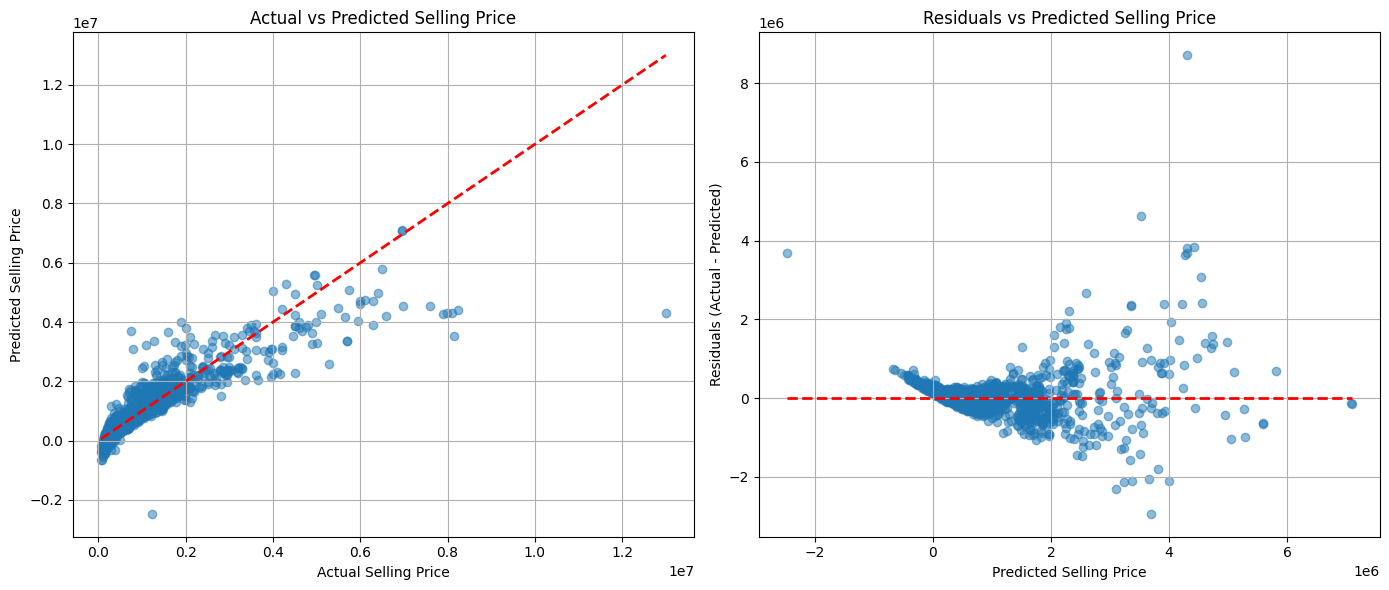


Analysis of Model Performance Visualizations:
1. **Actual vs Predicted Plot**: If points are clustered around the red diagonal line, it indicates good prediction. Deviations from the line show prediction errors.
   - Observation: Most points generally follow the diagonal line, especially for lower selling prices. However, there's significant spread for higher selling prices, suggesting the model struggles to predict these accurately. We also see some negative predictions, which are unrealistic for selling price.
2. **Residuals vs Predicted Plot**: Ideally, residuals should be randomly scattered around zero, with no discernible pattern. A pattern (e.g., a funnel shape, curve) indicates heteroscedasticity or that the model is missing important features/non-linear relationships.
   - Observation: The residuals show a clear pattern, widening as the predicted selling price increases. This 'funnel shape' indicates heteroscedasticity – the model's errors are not constant across the range of 

In [22]:
import matplotlib.pyplot as plt

# Flatten y_test_np for plotting
y_test_flat = y_test_np.flatten()
y_pred_flat = y_pred_test.flatten()

# Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Actual vs Predicted Selling Price
plt.subplot(1, 2, 1)
plt.scatter(y_test_flat, y_pred_flat, alpha=0.5)
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.grid(True)

# Subplot 2: Residuals Plot
# Residuals were already calculated as 'residuals'
# Need to flatten residuals if they are still 2D
residuals_flat = residuals.flatten()
plt.subplot(1, 2, 2)
plt.scatter(y_pred_flat, residuals_flat, alpha=0.5)
plt.hlines(y=0, xmin=y_pred_flat.min(), xmax=y_pred_flat.max(), colors='r', linestyles='--', lw=2)
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Selling Price')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nAnalysis of Model Performance Visualizations:")
print("1. **Actual vs Predicted Plot**: If points are clustered around the red diagonal line, it indicates good prediction. Deviations from the line show prediction errors.")
print("   - Observation: Most points generally follow the diagonal line, especially for lower selling prices. However, there's significant spread for higher selling prices, suggesting the model struggles to predict these accurately. We also see some negative predictions, which are unrealistic for selling price.")
print("2. **Residuals vs Predicted Plot**: Ideally, residuals should be randomly scattered around zero, with no discernible pattern. A pattern (e.g., a funnel shape, curve) indicates heteroscedasticity or that the model is missing important features/non-linear relationships.")
print("   - Observation: The residuals show a clear pattern, widening as the predicted selling price increases. This 'funnel shape' indicates heteroscedasticity – the model's errors are not constant across the range of predictions. This suggests that the linear model might be less accurate for higher-priced cars and that a simple linear relationship might not fully capture the complexity of the data, especially at higher values. There are also several large positive and negative residuals, indicating some significant over- and under-predictions.")
print("\nPossible reasons for prediction errors:")
print("- **Heteroscedasticity**: The variance of errors is not constant, which violates an assumption of OLS and can lead to less reliable coefficient estimates and confidence intervals.")
print("- **Missing Non-Linear Relationships**: The linear model might not capture non-linear relationships between features and the target variable, especially at higher price points.")
print("- **Outliers**: Some extreme values in actual selling prices or features might disproportionately influence the model.")
print("- **Multicollinearity**: Although we used a pseudo-inverse, high multicollinearity among features (especially one-hot encoded ones) can make coefficient estimates unstable and less interpretable.")
print("- **Limited Features / Feature Interactions**: The model might benefit from additional features or interaction terms that better explain the variance in selling price.")


### Task 20: Conclude

- Comment on the most influential features.
- Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction.
- Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.

## Conclusion

This experiment aimed to implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars from the CarDekho dataset.

### Most Influential Features
Based on the absolute values of the standardized regression coefficients, the most influential features in predicting car selling price were:
- **`max_power`**: Positively correlated, a significant driver of price.
- **`vehicle_age`**: Negatively correlated, older cars are generally cheaper.
- **`engine`**: Surprisingly negatively correlated, though this might be influenced by multicollinearity or specific market segments.
- **Categorical features like `brand_Ferrari` and `brand_Rolls-Royce`** had massive positive coefficients, indicating their significant premium status.

### Advantages of Multiple Linear Regression (OLS Implementation)
- **Simplicity and Interpretability**: The model is easy to understand, and the coefficients directly indicate the relationship between each feature and the target variable. This interpretability is a major advantage for business insights.
- **Foundation for Complex Models**: OLS is a fundamental algorithm, and implementing it from scratch provides a deep understanding of how linear models work.
- **Computational Efficiency**: For datasets where $(X^TX)^{-1}$ can be calculated, OLS provides a closed-form solution, making it computationally fast.

### Limitations for Used-Car Price Prediction
Despite an R² of approximately 0.7999, which suggests that our model explains about 80% of the variance in selling prices, several limitations were observed:

- **Heteroscedasticity**: The residuals plot clearly showed a 'funnel shape', indicating that the model's errors are not constant across all prediction ranges. This means the model is less reliable for predicting higher-priced cars, and the assumptions of OLS are violated, which can lead to inefficient (though still unbiased) coefficient estimates.
- **Negative Price Predictions**: The model occasionally predicted negative selling prices, which is unrealistic for real-world scenarios. This is a common issue with linear models when extrapolating or dealing with data near the boundary conditions of the target variable.
- **Linearity Assumption**: Used car prices often exhibit non-linear relationships with features (e.g., depreciation might not be strictly linear, or brand/model effects can be highly non-additive). A purely linear model might not capture these complexities.
- **Multicollinearity**: The initial check of the determinant of $(X^TX)$ being zero indicated multicollinearity. While `np.linalg.pinv` (pseudo-inverse) handled the computation, it can make individual coefficient interpretations less stable and reliable.
- **Outliers and Extreme Values**: High-end luxury cars (e.g., Ferrari, Rolls-Royce) represented extreme values in the dataset. While the model assigned very high coefficients to these, their rare occurrence and extreme nature can disproportionately influence the model and affect predictions for more common cars.
- **Missing Features / Interactions**: The model might benefit from additional features (e.g., car features like sunroof, safety ratings, color) or interaction terms between existing features that could explain more variance.

### Effectiveness of the Model

The Multiple Linear Regression model, as implemented, achieved a **Residual Sum of Squares (RSS) of 464,368,615,292,575.88** and an **R-squared (R²) of approximately 0.7999** on the test set. This R² value indicates a reasonably strong explanatory power, meaning the selected features and the linear model can explain a large portion of the variability in used car prices.

**However, the model's effectiveness is constrained by its inherent linear assumptions and the observed heteroscedasticity.** While it provides a good baseline and interpretable insights, its predictions for higher-priced cars are less reliable, and the presence of negative predictions highlights its limitations for practical deployment without further refinement (e.g., using log transformations on the target, more robust regression techniques, or non-linear models). The preprocessing steps, including one-hot encoding and standardization, were crucial in preparing the data for the linear model and enabling a fair comparison of feature influences.